# Global Video Game Sales ## Objective 1 :
Profile & QA the data

In [1]:
import pandas as pd

video_games = (
    pd.read_csv("vgchartz-2024.csv", parse_dates=["release_date"])
    .rename(
        {
            "title": "Title",
            "console": "Console",
            "genre": "Genre",
            "publisher": "Publisher",
            "developer": "Developer"
        },
        axis=1
    )
    .assign(release_year=lambda x: x["release_date"].dt.year)
)

video_games.head()

,img,Title,Console,Genre,Publisher,Developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,release_year
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN,2013.0
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03,2014.0
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN,2002.0
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN,2013.0
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14,2015.0


In [2]:
video_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   img           64016 non-null  object        
 1   Title         64016 non-null  object        
 2   Console       64016 non-null  object        
 3   Genre         64016 non-null  object        
 4   Publisher     64016 non-null  object        
 5   Developer     63999 non-null  object        
 6   critic_score  6678 non-null   float64       
 7   total_sales   18922 non-null  float64       
 8   na_sales      12637 non-null  float64       
 9   jp_sales      6726 non-null   float64       
 10  pal_sales     12824 non-null  float64       
 11  other_sales   15128 non-null  float64       
 12  release_date  56965 non-null  datetime64[ns]
 13  last_update   17879 non-null  object        
 14  release_year  56965 non-null  float64       
dtypes: datetime64[ns](1), float64(7), ob

In [3]:
video_games.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,release_year
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000,56965,56965.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041,2006-11-14 06:33:03.491617792,2006.359572
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1971-12-03 00:00:00,1971.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000,2001-03-28 00:00:00,2001.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000,2008-09-16 00:00:00,2008.000000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000,2012-12-27 00:00:00,2012.000000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000,2024-12-31 00:00:00,2024.000000
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643,NaN,8.617813


# Objective 2 :
Prepare the data for visualization

In [4]:
annual_sales = video_games.groupby("release_year", as_index=False).agg({"total_sales": "sum"})

annual_sales.tail()

,release_year,total_sales
46,2020.0,3.45
47,2021.0,0.00
48,2022.0,0.00
49,2023.0,0.00
50,2024.0,0.00


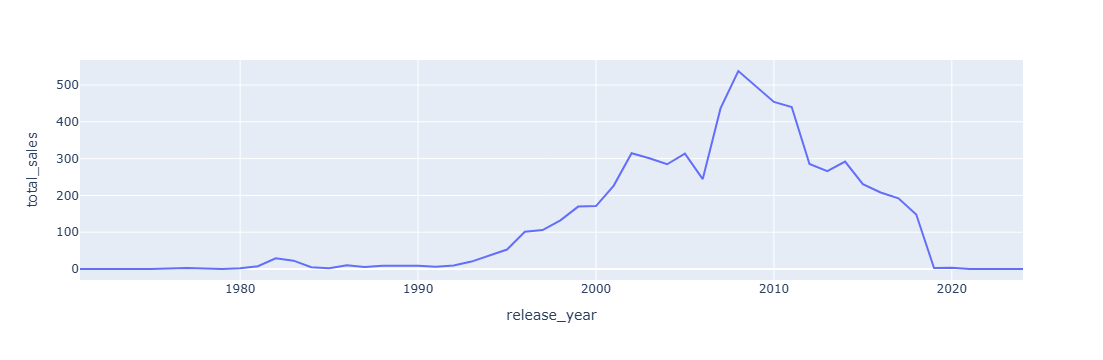

In [5]:
import plotly.express as px

px.line(annual_sales, x="release_year", y="total_sales")

In [6]:
top10_titles = (
    video_games
    .groupby("Title", as_index=False)
    .agg({"total_sales": "sum"})
    .sort_values("total_sales", ascending=False)
    .iloc[:10]
)

top10_titles.head(10)

,Title,total_sales
13724,Grand Theft Auto V,64.29
5266,Call of Duty: Black Ops,30.99
5281,Call of Duty: Modern Warfare 3,30.71
5273,Call of Duty: Black Ops II,29.59
5277,Call of Duty: Ghosts,28.80
5271,Call of Duty: Black Ops 3,26.72
5280,Call of Duty: Modern Warfare 2,25.02
20998,Minecraft,24.01
13719,Grand Theft Auto IV,22.53
5265,Call of Duty: Advanced Warfare,21.78


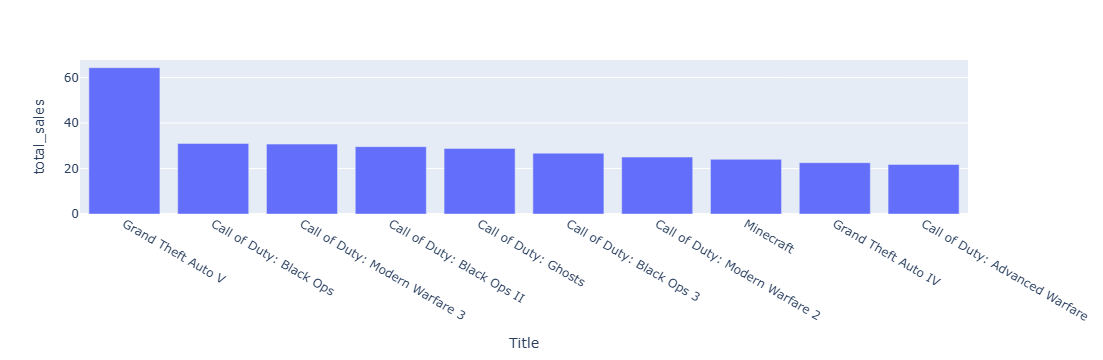

In [7]:
px.bar(top10_titles, x="Title", y="total_sales")

# Objective 3 :Build an interactive dashboard

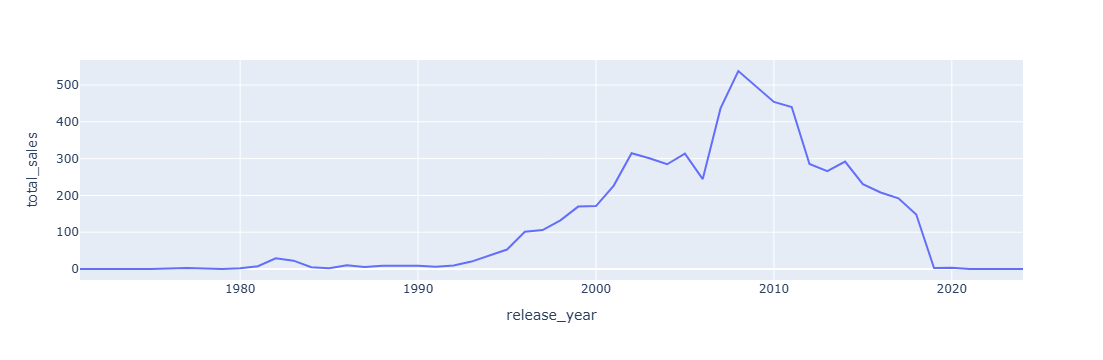

In [8]:
px.line(annual_sales, x="release_year", y="total_sales")

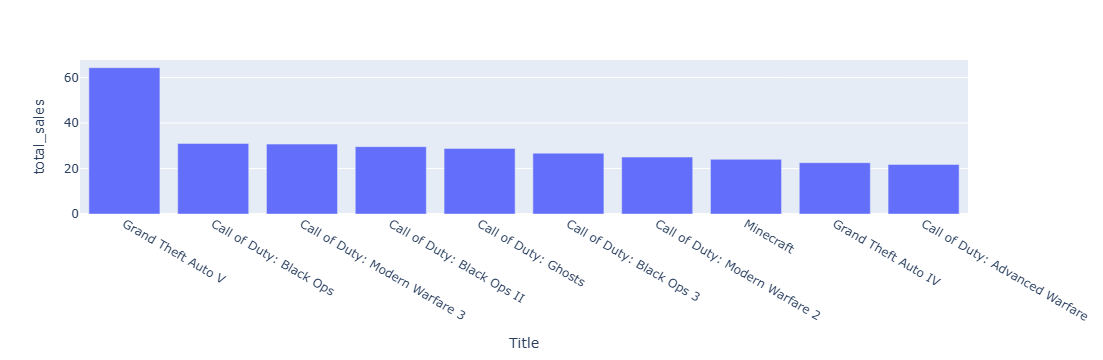

In [9]:
px.bar(top10_titles, x="Title", y="total_sales")

In [16]:
from dash import Dash, dcc, html
from dash.dependencies import Output, Input
from dash_bootstrap_templates import load_figure_template
import dash_bootstrap_components as dbc

import plotly.express as px
import pandas as pd
import numpy as np

# Load and prepare data
video_games = (
    pd.read_csv("vgchartz-2024.csv", parse_dates=["release_date"])
    .rename({
        "title": "Title",
        "console": "Console",
        "genre": "Genre",
        "publisher": "Publisher",
        "developer": "Developer"
    }, axis=1)
    .assign(release_year=lambda x: x["release_date"].dt.year)
)

dbc_css = "https://cdn.jsdelivr.net/gh/AnnMarieW/dash-bootstrap-templates/dbc.min.css"

app = Dash(__name__, external_stylesheets=[dbc.themes.CYBORG, dbc_css])

load_figure_template("CYBORG")

# Layout
app.layout = dbc.Container([
    html.H1("Video Game Explorer", style={"text-align": "center"}),
    dbc.Row([
    dbc.Col([
        dbc.Card([
            dcc.Markdown("**Select A Category**"),
            dcc.Dropdown(
                id="category-dropdown",
                options=[
                    {"label": "Title", "value": "Title"},
                    {"label": "Genre", "value": "Genre"},
                    {"label": "Publisher", "value": "Publisher"},
                    {"label": "Developer", "value": "Developer"},
                    {"label": "Console", "value": "Console"}
                ],
                value="Title",
                className="dbc"
            )
        ])
    ]),

    dbc.Col([
        dbc.Card([
            dcc.Markdown("**Select A Region**"),
            dcc.RadioItems(
                id="region-radio",
                options=[
                    {"label": "World Total", "value": "total_sales"},
                    {"label": "North America", "value": "na_sales"},
                    {"label": "Japan", "value": "jp_sales"},
                    {"label": "Europe/Africa", "value": "pal_sales"},
                    {"label": "Rest of World", "value": "other_sales"}
                ],
                value="total_sales",
                className="dbc"
            )
        ])
    ]),
]),
html.Br(),
dbc.Row(dcc.Graph(id="sales-line")),
html.Br(),
dbc.Row(dcc.Graph(id="rankings-bar")),
])

@app.callback(
    Output("sales-line", "figure"),
    Output("rankings-bar", "figure"),
    Input("category-dropdown", "value"),
    Input("region-radio", "value"),
)

def vg_plotter(category, region):

    # --- Line chart: Sales over time ---
    annual_sales = (
        video_games
        .groupby("release_year", as_index=False)[region]
        .sum()
    )

    fig = px.line(
        annual_sales,
        x="release_year",
        y=region,
        title=f"Video Game Sales in {region} Over Time"
    )

    fig.update_layout(title_x=0.5)

    # --- Bar chart: Top 10 sellers ---
    top10_sellers = (
        video_games
        .groupby(category, as_index=False)[region]
        .sum()
        .sort_values(by=region, ascending=False)
        .head(10)
    )

    fig2 = px.bar(
        top10_sellers,
        x=category,
        y=region,
        title="Top Video Game Sales by Category"
    )

    fig2.update_layout(title_x=0.5)

    return fig, fig2




# Run server
if __name__ == "__main__":
    app.run()